<a href="https://colab.research.google.com/github/SaiKumar77s/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SENTIMENT ANALYSIS**

Install Required Libraries

In [ ]:
!pip install kaggle nltk scikit-learn pandas matplotlib seaborn


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


Download NLTK Resources

In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from google.colab import files
files.upload()


Saving traning_data.csv to traning_data (1).csv


{'traning_data (1).csv': b'text,target\nwatched &quot;star trek&quot; with my sister last night..the movie finished at nearly 2:30am..look what I\'ve got! a pair of freaking eyebags!! ,negative\nThank you lawn men! I love being working up by lawn mowers ,positive\n@Dameunited (late reply) Thank you! I\'m glad I have your support ,positive\n@DowntownRob you\'re the king of scoring free eats!  must be karma from always sharing your space ,positive\n@elledeesee I\'m kinda thinkin u mite b a nympho... but I feel it\'s a healthy addiction ,positive\n@Amelia_Grace Because guys feel hurt too they just have a different way of showing it ,negative\n@greystonebar will let you know! i might grab one from Drinx ,positive\n"@tommcfly hey Tom, I\'m waiting for you back to Brazil cuz I didn\'t go to your last concert here  are you coming in October?",negative\n@deasaurr me too  awww,negative\n@trvsbrkr http://twitpic.com/4hvhs - She\'s cute ,positive\n@lauraduhaime @DocLG @TheTAZZone @mmangen @bradga

Understand the Data

In [ ]:
import pandas as pd

file_path = '/content/traning_data.csv'

df = pd.read_csv(file_path)

df.head()

,text,target
0,watched &quot;star trek&quot; with my sister l...,negative
1,Thank you lawn men! I love being working up by...,positive
2,@Dameunited (late reply) Thank you! I'm glad I...,positive
3,@DowntownRob you're the king of scoring free e...,positive
4,@elledeesee I'm kinda thinkin u mite b a nymph...,positive


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10000 non-null  object
 1   target  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
df['target'].value_counts()


,count
target,
negative,5000
positive,5000


Convert Labels to Meaningful Names

In [ ]:
df['target'] = df['target'].replace({0: 'negative', 4: 'positive'})
df['target'].value_counts()


,count
target,
negative,5000
positive,5000


Check Missing Values

In [ ]:
df.isnull().sum()


,0
text,0
target,0


Text Preprocessing

In [ ]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)       # remove mentions & hashtags
    text = re.sub(r'[^a-z\s]', '', text)        # remove numbers & symbols

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return ' '.join(words)


In [ ]:
df['clean_text'] = df['text'].apply(preprocess_text)
df.head()


,text,target,clean_text
0,watched &quot;star trek&quot; with my sister l...,negative,watch quotstar trekquot sister last nightth mo...
1,Thank you lawn men! I love being working up by...,positive,thank lawn men love work lawn mower
2,@Dameunited (late reply) Thank you! I'm glad I...,positive,late repli thank im glad support
3,@DowntownRob you're the king of scoring free e...,positive,your king score free eat must karma alway shar...
4,@elledeesee I'm kinda thinkin u mite b a nymph...,positive,im kinda thinkin u mite b nympho feel healthi ...


Feature Extraction (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['target']


Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Model Building (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7225

Classification Report:

              precision    recall  f1-score   support

    negative       0.73      0.70      0.71       987
    positive       0.72      0.74      0.73      1013

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



Confusion Matrix

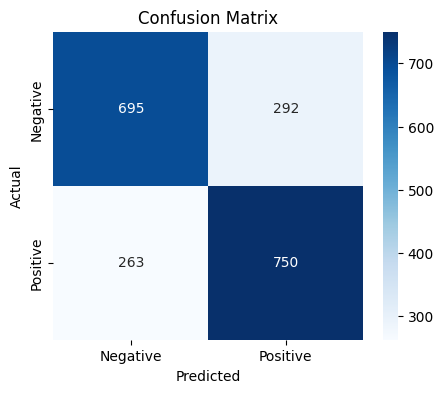

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Test with Custom Input

In [ ]:
def predict_sentiment(text):
    text = preprocess_text(text)
    vector = vectorizer.transform([text])
    return model.predict(vector)[0]


In [ ]:
predict_sentiment("I love this product, it is amazing")


'positive'

In [ ]:
predict_sentiment("Worst experience ever, very bad service")


'negative'

# **Insights & Conclusion**

• Logistic Regression achieved good accuracy for binary sentiment classification.

• TF-IDF effectively converted text into meaningful numerical features.

• Preprocessing improved performance by removing noise.

• The model correctly classifies positive and negative tweets.

• This approach can be extended using LSTM or BERT for better performance.

